Descripción...
<br>
Cargue los dataframes de interés y, además:
- Convierta energía de PE a MeV -> OJO CON HE SCALE, NECESITAMOS MISMO PROCESAMIENTO DE KR MAP.
- Aplique ventana del trigger 02.
- Selección $nS2 = 1$ para eventos fiduciales.
- Guardar información por run.
- Haga los plots de interés.

In [1]:
import sys
sys.path.append('/lhome/ific/c/ccortesp/Analysis/')

from libs import bckg_functions as bf
from libs import crudo
from libs import fit_functions as ff
from libs import plotting_tools as pt

import argparse
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import csv
import glob
from invisible_cities.reco.corrections import read_maps, apply_all_correction
from invisible_cities.types.symbols import NormStrategy
from invisible_cities.core.core_functions import in_range
from joblib import Parallel, delayed 
import numpy as np
import os
import pandas as pd
from scipy.interpolate import interp1d
from scipy.interpolate import griddata
from scipy.spatial.distance import cdist
from sklearn.neighbors import BallTree
from sklearn.neighbors import NearestNeighbors
from sklearn.exceptions import NotFittedError
from typing import List, Callable, Tuple

# Styling Plot
pt.ccortesp_plot_style()
# PRELIM_LOGO = np.asarray(Image.open('/lhome/ific/c/ccortesp/Analysis/images/next_logo_preliminary.png'))

%matplotlib inline
%load_ext autoreload
%autoreload 2

# Preliminary

In [5]:
# --------------------------------------------
# 1. DIRECTORIES, PATHS, KEYS AND FILENAMES
# --------------------------------------------
# FILENAME TAG
VERSION_TAG = 'p2_final'

# DIRECTORIES AND PATHS
INPUT_DIR = '/lustre/ific.uv.es/prj/gl/neutrinos/users/ccortesp/NEXT-100/Backgrounds/h5'

RUNS_INFO_PATH = os.path.join('/lhome/ific/c/ccortesp/Analysis/NEXT-100/Backgrounds/utilities/runs_information.csv')

SUMMARY_FILENAME = 'summary_' + VERSION_TAG + '_process.csv'     # Choose your name
SUMMARY_PATH = os.path.join('/lhome/ific/c/ccortesp/Analysis/NEXT-100/Backgrounds/txt/', SUMMARY_FILENAME)

# KEYS
DORO_KEY = 'DST/Events'
SOPH_KEY = 'RECO/Events'
EVT_KEY  = 'PROCESSED/Events'

# COLUMNS TO USE
DORO_COLUMNS = ['event', 'time', 'nS1', 'nS2', 'S1h', 'S1e', 'S2e', 'DT', 'X', 'Y', 'Z']
SOPH_COLUMNS = ['event', 'time', 'npeak', 'X', 'Y', 'Z', 'Q', 'E']
FINAL_SOPH_COLUMNS = ['event', 'time', 'npeak', 'X', 'Y', 'DT', 'Z', 'E_hit_pe']

# CUTFLOWS
CUT_NAMES = ['Reconstructed', 'Z_Positive', 'S1_Cut', 'Clean_Hits']

# --------------------------------
# 2. SELECTION
# --------------------------------
# --- High Energy Scale Correction ---
M_HE_SCALE = 4.80e-06
B_HE_SCALE = 0.0094         # in [MeV] 
DEP_CORRECTION = 0.0695     # in [MeV], ajustando al DEP

# --- Trigger 2 Efficiency Cut ---
# Events with event-level energy below this are removed to account for trigger efficiency.
TRG2_THRESHOLD = 0.5   # in [MeV]

# --------------------------------
# 3. PLOTS SETTINGS
# --------------------------------
# From merged_corr_time.txt
RAS_OFF_CORRECTED_TIME = 697798.6254801187      # in [s]
RAS_ON_CORRECTED_TIME  = 3485614.533823055      # in [s]

# Geometric boundaries for event classification.
Z_LOW = 40          # in [mm]
Z_UP  = 1147        # in [mm]
R_UP  = 451.65      # in [mm]

## Runs & Summary Information

In [6]:
# ----- Load Dataframes ----- #
RUNS_INFO_DF = pd.read_csv(RUNS_INFO_PATH)
RUNS_INFO_DF.columns = RUNS_INFO_DF.columns.str.strip()
RUNS_INFO_DF

,run_number,duration,OK,LOST,period,condition
0,15062,84783,69564,1339,1,castle_open
1,15063,79120,65052,1241,1,castle_open
2,15076,69316,56775,1080,1,castle_open
3,15288,87256,30201,8397,1,castle_pclosed_RAS
4,15289,82152,28180,7884,1,castle_pclosed_RAS
...,...,...,...,...,...,...
106,15733,86919,30475,10027,2,castle_closed_RAS
107,15734,85790,29837,9598,2,castle_closed_RAS
108,15735,87451,30547,9958,2,castle_closed_RAS
109,15736,93376,32622,10506,2,castle_closed_RAS


In [7]:
SUMMARY_DF = pd.read_csv(SUMMARY_PATH)
# Drop columns without names (empty column names)
SUMMARY_DF.drop(columns=['Unnamed: 0'], inplace=True)
SUMMARY_DF.columns = SUMMARY_DF.columns.str.strip()
SUMMARY_DF.sort_values(by='Run_ID', inplace=True)
SUMMARY_DF

,Run_ID,Duration,Date_CV,Date_Err,OK,LOST,Reconstructed,Z_Positive,S1_Cut,Clean_Events
40,15609,79563,1.753150e+09,167.3591,28168,8392,27865,20667,17703,17695
42,15614,81279,1.753244e+09,171.2587,28543,8472,28225,20811,17664,17656
44,15615,86302,1.753328e+09,174.9253,30165,9046,29767,21927,18634,18629
46,15616,86146,1.753414e+09,174.7854,30386,8635,30124,22198,18919,18907
47,15617,88041,1.753502e+09,175.5444,31274,8983,31052,22945,19591,19584
...,...,...,...,...,...,...,...,...,...,...
59,15733,86919,1.758939e+09,175.0674,30475,10027,30144,22120,18663,18657
62,15734,85790,1.759026e+09,176.3823,29837,9598,29513,21813,18275,18261
64,15735,87451,1.759113e+09,175.5591,30547,9958,30193,22198,18810,18801
66,15736,93376,1.759204e+09,181.1218,32622,10506,32243,23718,20280,20272


### Working in Period 02

In [9]:
# ----- Configuration ----- #
DATA_PERIOD = 2                 # Options: 1, 2
DETECTOR_CONDITION = None       # Options: None, 'castle_open', 'castle_closed', 'castle_closed_RAS', 'castle_pclosed', 'castle_pclosed_RAS'

In [10]:
# Select runs to use according to the notebook configuration
if DATA_PERIOD is not None:
    runs_to_analyze = RUNS_INFO_DF.loc[RUNS_INFO_DF['period'] == DATA_PERIOD, 'run_number'].values
    if DETECTOR_CONDITION is not None:
        runs_to_analyze = RUNS_INFO_DF.loc[(RUNS_INFO_DF['period'] == DATA_PERIOD) & (RUNS_INFO_DF['condition'] == DETECTOR_CONDITION), 'run_number'].values

# Selection
print(f"You have {len(runs_to_analyze)} runs to analyze:")
print(runs_to_analyze)

You have 67 runs to analyze:
[15609 15614 15615 15616 15617 15618 15619 15621 15622 15623 15624 15625
 15626 15627 15632 15633 15634 15635 15636 15637 15639 15640 15642 15643
 15644 15645 15647 15648 15649 15650 15655 15656 15657 15658 15659 15669
 15670 15671 15672 15673 15675 15676 15681 15682 15687 15688 15689 15693
 15694 15695 15696 15697 15698 15699 15700 15701 15709 15724 15729 15730
 15731 15732 15733 15734 15735 15736 15737]


In [ ]:
# # Esto se puede borrar luego
# Pau_df = SUMMARY_DF.loc[SUMMARY_DF['Run_ID'].isin(runs_to_analyze)]
# Pau_df = Pau_df[['Run_ID']]
# Pau_df.to_csv('runs_to_use.csv', index=False, sep=',', line_terminator=',\n')

### Dictionary for Final Summary
This includes selection cuts!

In [11]:
# UTILIZAR AQUÍ CUTFLOW ACTUALIZADO
EVT_COUNT_PER_RUN = {run: {'Trg2_Cut': 0, 'nElectrons': 0, 'S2_Cut': 0, 'nElectron_Fiducial': 0} for run in runs_to_analyze}

## Load Merged/Tagged Dataframes

In [12]:
# RAS = off
h5_filename = f'merged_tagged_runs_castle_closed_{VERSION_TAG}.h5'
RAS_OFF_DF = pd.read_hdf(os.path.join(INPUT_DIR, h5_filename), key='Events')
RAS_OFF_DF

,event,npeak,E_peak_pe,n_hits_peak,X_bary,Y_bary,Z_bary,Z_min,Z_max,R_max,...,time,nS1,nS2,S1e_max,S1e_corr_max,n_hits_original,run_number,global_event,particle,region
0,729,27,1.088816e+06,7736,64.465804,-198.521221,1184.605694,1164.560204,1205.445619,492.644427,...,1.753110e+09,1,1,1375.999634,1377.983858,8251,15609,0,alpha,cathode
1,1135,24,1.071127e+06,6951,20.125879,-285.444652,1185.351586,1166.460069,1203.718106,494.657494,...,1.753110e+09,1,1,1288.578125,1289.435936,7591,15609,1,alpha,cathode
2,2066,22,2.652837e+05,568,56.829979,448.314182,322.837112,315.182645,331.176387,503.637966,...,1.753110e+09,1,1,899.579102,1407.285688,1263,15609,2,alpha,tube
3,2297,18,2.738256e+05,607,262.824232,361.850465,706.187590,694.058916,720.928844,502.607786,...,1.753110e+09,1,1,1148.663696,1437.162886,1175,15609,3,alpha,tube
4,3144,30,1.060969e+06,7376,196.628390,-43.770213,1184.714681,1165.832511,1206.631642,492.459741,...,1.753110e+09,1,1,1457.166504,1458.044011,7937,15609,4,alpha,cathode
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
209908,1554427,31,1.538204e+05,349,302.245349,340.440730,400.622225,391.827376,411.444927,500.128125,...,1.754037e+09,1,1,900.591003,1340.967719,699,15624,197770,alpha,tube
209909,1554455,27,1.347803e+05,339,232.762543,-396.895344,779.189804,766.331396,796.838108,499.618561,...,1.754037e+09,1,1,1088.411743,1312.204418,595,15624,197771,alpha,tube
209910,1554567,25,2.929788e+05,583,460.451347,-17.398265,228.905920,220.902835,240.686358,498.898292,...,1.754037e+09,1,1,797.864563,1329.433384,1311,15624,197772,alpha,tube
209911,1554910,21,1.033557e+05,196,-380.598360,-262.627481,228.273411,222.587963,235.062777,491.851900,...,1.754037e+09,1,1,642.648376,1071.320454,594,15624,197773,alpha,tube


In [13]:
# RAS = on
h5_ras_filename = f'merged_tagged_runs_castle_closed_RAS_{VERSION_TAG}.h5'
RAS_ON_DF = pd.read_hdf(os.path.join(INPUT_DIR, h5_ras_filename), key='Events')
RAS_ON_DF

,event,npeak,E_peak_pe,n_hits_peak,X_bary,Y_bary,Z_bary,Z_min,Z_max,R_max,...,time,nS1,nS2,S1e_max,S1e_corr_max,n_hits_original,run_number,global_event,particle,region
0,1058,38,1.090162e+06,7661,79.117699,-221.253532,1184.932936,1165.845054,1203.139853,490.359033,...,1.754042e+09,1,1,1348.162720,1349.401861,8233,15625,0,alpha,cathode
1,2206,28,8.967802e+04,394,-311.729011,-80.132530,798.984606,780.906971,818.263077,394.051458,...,1.754042e+09,1,1,89.690819,106.929964,830,15625,1,electron,fiducial
2,3102,28,1.058786e+05,293,-383.024576,249.118346,136.800675,136.444451,145.976535,572.328604,...,1.754042e+09,0,1,NaN,NaN,869,15625,2,electron,anode
3,5461,34,2.913304e+05,655,-245.022549,376.699937,347.217012,338.059516,357.730589,506.456964,...,1.754042e+09,1,1,902.388672,1389.357608,1380,15625,3,alpha,tube
4,6126,34,2.222232e+05,386,-424.024260,-164.794798,542.387261,532.266397,555.681839,488.325226,...,1.754042e+09,1,1,1024.439575,1401.461476,773,15625,4,alpha,tube
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1005357,1789053,29,1.055424e+06,7066,87.489762,262.543864,1184.827340,1163.695637,1204.315713,500.173456,...,1.759302e+09,1,1,1407.644653,1408.771974,7630,15737,939939,alpha,cathode
1005358,1789270,26,1.078804e+06,7528,147.179688,162.105359,1184.800096,1164.829003,1205.627917,493.221716,...,1.759302e+09,1,1,1378.959717,1379.852927,8047,15737,939940,alpha,cathode
1005359,1790145,32,9.433251e+05,6762,-26.223840,114.451979,40.558259,22.576392,59.904061,490.317200,...,1.759302e+09,0,1,NaN,NaN,7346,15737,939941,alpha,anode
1005360,1790215,33,1.149728e+06,8830,-15.866651,-142.595750,897.990197,881.601513,915.386142,492.644427,...,1.759302e+09,1,1,1307.270386,1486.666484,9115,15737,939942,alpha,tube


# Trigger02 Cut: or energy window

In [14]:
# ----- RAS: OFF ----- #
# Convert from [pe] to [MeV] using HE scale
RAS_OFF_DF = bf.energy_pe_to_mev(RAS_OFF_DF, slope=M_HE_SCALE, intercept=B_HE_SCALE - DEP_CORRECTION, input_column='E_evt_pe', output_column='E_evt_mev')
RAS_OFF_DF

,event,npeak,E_peak_pe,n_hits_peak,X_bary,Y_bary,Z_bary,Z_min,Z_max,R_max,...,nS1,nS2,S1e_max,S1e_corr_max,n_hits_original,run_number,global_event,particle,region,E_evt_mev
0,729,27,1.088816e+06,7736,64.465804,-198.521221,1184.605694,1164.560204,1205.445619,492.644427,...,1,1,1375.999634,1377.983858,8251,15609,0,alpha,cathode,5.166217
1,1135,24,1.071127e+06,6951,20.125879,-285.444652,1185.351586,1166.460069,1203.718106,494.657494,...,1,1,1288.578125,1289.435936,7591,15609,1,alpha,cathode,5.081308
2,2066,22,2.652837e+05,568,56.829979,448.314182,322.837112,315.182645,331.176387,503.637966,...,1,1,899.579102,1407.285688,1263,15609,2,alpha,tube,1.213262
3,2297,18,2.738256e+05,607,262.824232,361.850465,706.187590,694.058916,720.928844,502.607786,...,1,1,1148.663696,1437.162886,1175,15609,3,alpha,tube,1.254263
4,3144,30,1.060969e+06,7376,196.628390,-43.770213,1184.714681,1165.832511,1206.631642,492.459741,...,1,1,1457.166504,1458.044011,7937,15609,4,alpha,cathode,5.032552
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
209908,1554427,31,1.538204e+05,349,302.245349,340.440730,400.622225,391.827376,411.444927,500.128125,...,1,1,900.591003,1340.967719,699,15624,197770,alpha,tube,0.678238
209909,1554455,27,1.347803e+05,339,232.762543,-396.895344,779.189804,766.331396,796.838108,499.618561,...,1,1,1088.411743,1312.204418,595,15624,197771,alpha,tube,0.586845
209910,1554567,25,2.929788e+05,583,460.451347,-17.398265,228.905920,220.902835,240.686358,498.898292,...,1,1,797.864563,1329.433384,1311,15624,197772,alpha,tube,1.346198
209911,1554910,21,1.033557e+05,196,-380.598360,-262.627481,228.273411,222.587963,235.062777,491.851900,...,1,1,642.648376,1071.320454,594,15624,197773,alpha,tube,0.436008


In [15]:
# Trigger2 Efficiency Cut
trg2_mask_off = (RAS_OFF_DF['E_evt_mev'] >= TRG2_THRESHOLD)
trg2_good_ids_off = RAS_OFF_DF.loc[trg2_mask_off, 'global_event'].unique()
RAS_OFF_DF = RAS_OFF_DF.loc[RAS_OFF_DF['global_event'].isin(trg2_good_ids_off)].copy()

# Update EVT_COUNT_PER_RUN
for run_id in RAS_OFF_DF['run_number'].unique():

    run_mask = (RAS_OFF_DF['run_number'] == run_id)
    after_trg2_ids = RAS_OFF_DF.loc[run_mask, 'global_event'].unique()
    EVT_COUNT_PER_RUN[run_id]['Trg2_Cut'] = len(after_trg2_ids)

In [53]:
print(RAS_OFF_DF['global_event'].nunique())
RAS_OFF_DF

148468


,event,npeak,E_peak_pe,n_hits_peak,X_bary,Y_bary,Z_bary,Z_min,Z_max,R_max,...,nS1,nS2,S1e_max,S1e_corr_max,n_hits_original,run_number,global_event,particle,region,E_evt_mev
0,729,27,1.088816e+06,7736,64.465804,-198.521221,1184.605694,1164.560204,1205.445619,492.644427,...,1,1,1375.999634,1377.983858,8251,15609,0,alpha,cathode,5.166217
1,1135,24,1.071127e+06,6951,20.125879,-285.444652,1185.351586,1166.460069,1203.718106,494.657494,...,1,1,1288.578125,1289.435936,7591,15609,1,alpha,cathode,5.081308
2,2066,22,2.652837e+05,568,56.829979,448.314182,322.837112,315.182645,331.176387,503.637966,...,1,1,899.579102,1407.285688,1263,15609,2,alpha,tube,1.213262
3,2297,18,2.738256e+05,607,262.824232,361.850465,706.187590,694.058916,720.928844,502.607786,...,1,1,1148.663696,1437.162886,1175,15609,3,alpha,tube,1.254263
4,3144,30,1.060969e+06,7376,196.628390,-43.770213,1184.714681,1165.832511,1206.631642,492.459741,...,1,1,1457.166504,1458.044011,7937,15609,4,alpha,cathode,5.032552
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
209907,1554364,18,6.163523e+05,2837,-222.642644,15.764808,1184.691236,1166.744221,1204.145199,477.673363,...,1,1,872.876221,873.646791,3993,15624,197769,electron,cathode,2.898391
209908,1554427,31,1.538204e+05,349,302.245349,340.440730,400.622225,391.827376,411.444927,500.128125,...,1,1,900.591003,1340.967719,699,15624,197770,alpha,tube,0.678238
209909,1554455,27,1.347803e+05,339,232.762543,-396.895344,779.189804,766.331396,796.838108,499.618561,...,1,1,1088.411743,1312.204418,595,15624,197771,alpha,tube,0.586845
209910,1554567,25,2.929788e+05,583,460.451347,-17.398265,228.905920,220.902835,240.686358,498.898292,...,1,1,797.864563,1329.433384,1311,15624,197772,alpha,tube,1.346198


In [16]:
# ----- RAS: ON ----- #
# Convert from [pe] to [MeV] using HE scale
RAS_ON_DF = bf.energy_pe_to_mev(RAS_ON_DF, slope=M_HE_SCALE, intercept=B_HE_SCALE, input_column='E_evt_pe', output_column='E_evt_mev')
RAS_ON_DF


,event,npeak,E_peak_pe,n_hits_peak,X_bary,Y_bary,Z_bary,Z_min,Z_max,R_max,...,nS1,nS2,S1e_max,S1e_corr_max,n_hits_original,run_number,global_event,particle,region,E_evt_mev
0,1058,38,1.090162e+06,7661,79.117699,-221.253532,1184.932936,1165.845054,1203.139853,490.359033,...,1,1,1348.162720,1349.401861,8233,15625,0,alpha,cathode,5.242177
1,2206,28,8.967802e+04,394,-311.729011,-80.132530,798.984606,780.906971,818.263077,394.051458,...,1,1,89.690819,106.929964,830,15625,1,electron,fiducial,0.439854
2,3102,28,1.058786e+05,293,-383.024576,249.118346,136.800675,136.444451,145.976535,572.328604,...,0,1,NaN,NaN,869,15625,2,electron,anode,0.517617
3,5461,34,2.913304e+05,655,-245.022549,376.699937,347.217012,338.059516,357.730589,506.456964,...,1,1,902.388672,1389.357608,1380,15625,3,alpha,tube,1.407786
4,6126,34,2.222232e+05,386,-424.024260,-164.794798,542.387261,532.266397,555.681839,488.325226,...,1,1,1024.439575,1401.461476,773,15625,4,alpha,tube,1.076072
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1005357,1789053,29,1.055424e+06,7066,87.489762,262.543864,1184.827340,1163.695637,1204.315713,500.173456,...,1,1,1407.644653,1408.771974,7630,15737,939939,alpha,cathode,5.075436
1005358,1789270,26,1.078804e+06,7528,147.179688,162.105359,1184.800096,1164.829003,1205.627917,493.221716,...,1,1,1378.959717,1379.852927,8047,15737,939940,alpha,cathode,5.187660
1005359,1790145,32,9.433251e+05,6762,-26.223840,114.451979,40.558259,22.576392,59.904061,490.317200,...,0,1,NaN,NaN,7346,15737,939941,alpha,anode,4.537360
1005360,1790215,33,1.149728e+06,8830,-15.866651,-142.595750,897.990197,881.601513,915.386142,492.644427,...,1,1,1307.270386,1486.666484,9115,15737,939942,alpha,tube,5.528093


In [17]:
# Trigger2 Efficiency Cut
trg2_mask_on = (RAS_ON_DF['E_evt_mev'] >= TRG2_THRESHOLD)
trg2_good_ids_on = RAS_ON_DF.loc[trg2_mask_on, 'global_event'].unique()
RAS_ON_DF = RAS_ON_DF.loc[RAS_ON_DF['global_event'].isin(trg2_good_ids_on)].copy()

# Update EVT_COUNT_PER_RUN
for run_id in RAS_ON_DF['run_number'].unique():

    run_mask = (RAS_ON_DF['run_number'] == run_id)
    after_trg2_ids = RAS_ON_DF.loc[run_mask, 'global_event'].unique()
    EVT_COUNT_PER_RUN[run_id]['Trg2_Cut'] = len(after_trg2_ids)

In [19]:
print(len(trg2_good_ids_on))

769522


In [18]:
print(RAS_ON_DF['global_event'].nunique())
RAS_ON_DF

769522


,event,npeak,E_peak_pe,n_hits_peak,X_bary,Y_bary,Z_bary,Z_min,Z_max,R_max,...,nS1,nS2,S1e_max,S1e_corr_max,n_hits_original,run_number,global_event,particle,region,E_evt_mev
0,1058,38,1.090162e+06,7661,79.117699,-221.253532,1184.932936,1165.845054,1203.139853,490.359033,...,1,1,1348.162720,1349.401861,8233,15625,0,alpha,cathode,5.242177
2,3102,28,1.058786e+05,293,-383.024576,249.118346,136.800675,136.444451,145.976535,572.328604,...,0,1,NaN,NaN,869,15625,2,electron,anode,0.517617
3,5461,34,2.913304e+05,655,-245.022549,376.699937,347.217012,338.059516,357.730589,506.456964,...,1,1,902.388672,1389.357608,1380,15625,3,alpha,tube,1.407786
4,6126,34,2.222232e+05,386,-424.024260,-164.794798,542.387261,532.266397,555.681839,488.325226,...,1,1,1024.439575,1401.461476,773,15625,4,alpha,tube,1.076072
5,6133,22,1.984393e+05,309,-353.215390,-294.146186,285.551141,276.370095,295.972293,488.360253,...,1,1,756.274536,1212.535025,719,15625,5,alpha,tube,0.961909
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1005357,1789053,29,1.055424e+06,7066,87.489762,262.543864,1184.827340,1163.695637,1204.315713,500.173456,...,1,1,1407.644653,1408.771974,7630,15737,939939,alpha,cathode,5.075436
1005358,1789270,26,1.078804e+06,7528,147.179688,162.105359,1184.800096,1164.829003,1205.627917,493.221716,...,1,1,1378.959717,1379.852927,8047,15737,939940,alpha,cathode,5.187660
1005359,1790145,32,9.433251e+05,6762,-26.223840,114.451979,40.558259,22.576392,59.904061,490.317200,...,0,1,NaN,NaN,7346,15737,939941,alpha,anode,4.537360
1005360,1790215,33,1.149728e+06,8830,-15.866651,-142.595750,897.990197,881.601513,915.386142,492.644427,...,1,1,1307.270386,1486.666484,9115,15737,939942,alpha,tube,5.528093


# Inclusive Electrons

In [56]:
# RAS OFF
ELEC_INCL_RAS_OFF_DF = RAS_OFF_DF[RAS_OFF_DF['particle'] == 'electron'].copy()
ELEC_INCL_RAS_OFF_DF

,event,npeak,E_peak_pe,n_hits_peak,X_bary,Y_bary,Z_bary,Z_min,Z_max,R_max,...,nS1,nS2,S1e_max,S1e_corr_max,n_hits_original,run_number,global_event,particle,region,E_evt_mev
17,15002,15,52520.677316,203,-214.302168,57.682509,701.117386,453.067213,820.823909,470.463252,...,1,4,343.690796,492.662908,1915,15609,16,electron,tube,1.523576
18,15002,16,38134.169262,179,-214.302168,57.682509,701.117386,453.067213,820.823909,470.463252,...,1,4,343.690796,492.662908,1915,15609,16,electron,tube,1.523576
19,15002,17,3333.820538,24,-214.302168,57.682509,701.117386,453.067213,820.823909,470.463252,...,1,4,343.690796,492.662908,1915,15609,16,electron,tube,1.523576
20,15002,18,235943.910810,909,-214.302168,57.682509,701.117386,453.067213,820.823909,470.463252,...,1,4,343.690796,492.662908,1915,15609,16,electron,tube,1.523576
36,28652,29,177955.267983,546,-413.580443,-107.188638,107.352626,68.115398,139.957108,488.325226,...,1,1,123.414467,227.225050,834,15609,32,electron,tube,0.794085
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
209839,1500016,46,6828.645069,42,8.275598,-116.269832,534.009954,471.906697,1332.670251,437.182829,...,1,2,86.608429,122.583125,913,15624,197702,electron,cathode,0.564536
209841,1500478,27,121795.210536,536,13.819360,187.122195,1020.345815,996.927746,1041.277701,263.851343,...,1,1,146.928253,157.787784,815,15624,197704,electron,fiducial,0.524517
209874,1524831,15,126577.342348,477,-414.594559,-40.716633,956.735311,938.946471,972.788947,485.008548,...,1,1,179.425034,198.471606,781,15624,197736,electron,tube,0.547471
209882,1530613,26,180532.156695,417,-359.820815,269.416263,16.650926,5.297801,28.508994,499.230980,...,0,1,NaN,NaN,843,15624,197744,electron,anode,0.806454


In [57]:
# Update EVT_COUNT_PER_RUN
for run_id in ELEC_INCL_RAS_OFF_DF['run_number'].unique():

    run_mask = (ELEC_INCL_RAS_OFF_DF['run_number'] == run_id)
    inclusive_ids = ELEC_INCL_RAS_OFF_DF.loc[run_mask, 'global_event'].unique()
    EVT_COUNT_PER_RUN[run_id]['nElectrons'] = len(inclusive_ids)

In [58]:
# RAS OFF
ELEC_INCL_RAS_ON_DF = RAS_ON_DF[RAS_ON_DF['particle'] == 'electron'].copy()
ELEC_INCL_RAS_ON_DF

,event,npeak,E_peak_pe,n_hits_peak,X_bary,Y_bary,Z_bary,Z_min,Z_max,R_max,...,nS1,nS2,S1e_max,S1e_corr_max,n_hits_original,run_number,global_event,particle,region,E_evt_mev
2,3102,28,105878.602295,293,-383.024576,249.118346,136.800675,136.444451,145.976535,572.328604,...,0,1,NaN,NaN,869,15625,2,electron,anode,0.517617
21,16416,39,507654.634918,2610,153.242465,-59.128367,814.948924,789.301255,847.492616,498.469725,...,1,1,578.695923,687.353834,3510,15625,21,electron,tube,2.446142
28,24179,38,147404.216751,417,-251.670536,365.606790,321.436811,304.616346,338.565109,498.467844,...,1,1,129.498611,202.565292,758,15625,28,electron,tube,0.716940
32,26181,30,130226.652027,410,38.554585,247.627791,318.886611,261.444088,381.408775,339.263506,...,1,1,90.630959,146.678337,750,15625,32,electron,fiducial,0.634488
40,30920,28,312293.863779,1099,108.943233,-121.984925,305.257621,280.342607,337.997561,294.945709,...,1,1,237.644119,376.526013,1612,15625,40,electron,fiducial,1.508411
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1005311,1747949,31,110227.156756,298,314.892995,-246.857926,22.116870,4.768529,38.186723,478.361695,...,0,1,NaN,NaN,500,15737,939899,electron,anode,0.538490
1005321,1757637,25,97136.544046,260,102.497306,159.552241,67.881718,18.287398,261.671799,487.977096,...,0,2,NaN,NaN,663,15737,939907,electron,anode,0.581885
1005322,1757637,26,22131.080577,81,102.497306,159.552241,67.881718,18.287398,261.671799,487.977096,...,0,2,NaN,NaN,663,15737,939907,electron,anode,0.581885
1005340,1774157,23,635195.231866,3088,129.104012,-7.037664,1186.062069,1168.705176,1206.102262,489.914917,...,1,1,884.176819,884.557759,4126,15737,939922,electron,cathode,3.058337


In [59]:
# Update EVT_COUNT_PER_RUN
for run_id in ELEC_INCL_RAS_ON_DF['run_number'].unique():

    run_mask = (ELEC_INCL_RAS_ON_DF['run_number'] == run_id)
    inclusive_ids = ELEC_INCL_RAS_ON_DF.loc[run_mask, 'global_event'].unique()
    EVT_COUNT_PER_RUN[run_id]['nElectrons'] = len(inclusive_ids)

# Fiducial Electrons

## $nS2=1$

In [60]:
# RAS OFF
s2_mask_off = (ELEC_INCL_RAS_OFF_DF['nS2'] == 1)
s2_good_ids_off = ELEC_INCL_RAS_OFF_DF.loc[s2_mask_off, 'global_event'].unique()
ELEC_FIDU_RAS_OFF_DF = ELEC_INCL_RAS_OFF_DF.loc[ELEC_INCL_RAS_OFF_DF['global_event'].isin(s2_good_ids_off)].copy()

# Update EVT_COUNT_PER_RUN
for run_id in ELEC_FIDU_RAS_OFF_DF['run_number'].unique():

    run_mask = (ELEC_FIDU_RAS_OFF_DF['run_number'] == run_id)
    after_s2_ids = ELEC_FIDU_RAS_OFF_DF.loc[run_mask, 'global_event'].unique()
    EVT_COUNT_PER_RUN[run_id]['S2_Cut'] = len(after_s2_ids)

In [61]:
ELEC_FIDU_RAS_OFF_DF

,event,npeak,E_peak_pe,n_hits_peak,X_bary,Y_bary,Z_bary,Z_min,Z_max,R_max,...,nS1,nS2,S1e_max,S1e_corr_max,n_hits_original,run_number,global_event,particle,region,E_evt_mev
36,28652,29,177955.267983,546,-413.580443,-107.188638,107.352626,68.115398,139.957108,488.325226,...,1,1,123.414467,227.225050,834,15609,32,electron,tube,0.794085
56,56932,18,146843.568552,642,-39.811567,-367.077995,1176.668849,1152.388033,1200.375638,453.619038,...,1,1,190.823578,191.569690,937,15609,51,electron,cathode,0.644749
65,69791,23,122614.766194,482,-67.922205,-51.682112,369.060684,327.721685,392.609768,149.347050,...,1,1,107.110825,162.890552,779,15609,59,electron,fiducial,0.528451
66,70988,27,133456.374630,598,61.789180,382.605815,1173.769324,1152.331483,1193.410766,482.753106,...,1,1,154.641434,155.527977,819,15609,60,electron,cathode,0.580491
68,72549,31,298843.496074,850,384.604760,221.347721,9.123899,5.621419,28.591926,578.582441,...,0,1,NaN,NaN,1721,15609,62,electron,anode,1.374349
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
209821,1491931,35,137960.771326,535,24.728306,-237.439293,645.985219,618.103483,693.388974,311.008185,...,1,1,140.047073,181.758886,818,15624,197687,electron,fiducial,0.602112
209841,1500478,27,121795.210536,536,13.819360,187.122195,1020.345815,996.927746,1041.277701,263.851343,...,1,1,146.928253,157.787784,815,15624,197704,electron,fiducial,0.524517
209874,1524831,15,126577.342348,477,-414.594559,-40.716633,956.735311,938.946471,972.788947,485.008548,...,1,1,179.425034,198.471606,781,15624,197736,electron,tube,0.547471
209882,1530613,26,180532.156695,417,-359.820815,269.416263,16.650926,5.297801,28.508994,499.230980,...,0,1,NaN,NaN,843,15624,197744,electron,anode,0.806454


In [62]:
# RAS ON
s2_mask_on = (ELEC_INCL_RAS_ON_DF['nS2'] == 1)
s2_good_ids_on = ELEC_INCL_RAS_ON_DF.loc[s2_mask_on, 'global_event'].unique()
ELEC_FIDU_RAS_ON_DF = ELEC_INCL_RAS_ON_DF.loc[ELEC_INCL_RAS_ON_DF['global_event'].isin(s2_good_ids_on)].copy()

# Update EVT_COUNT_PER_RUN
for run_id in ELEC_FIDU_RAS_ON_DF['run_number'].unique():

    run_mask = (ELEC_FIDU_RAS_ON_DF['run_number'] == run_id)
    after_s2_ids = ELEC_FIDU_RAS_ON_DF.loc[run_mask, 'global_event'].unique()
    EVT_COUNT_PER_RUN[run_id]['S2_Cut'] = len(after_s2_ids)

In [63]:
ELEC_FIDU_RAS_ON_DF

,event,npeak,E_peak_pe,n_hits_peak,X_bary,Y_bary,Z_bary,Z_min,Z_max,R_max,...,nS1,nS2,S1e_max,S1e_corr_max,n_hits_original,run_number,global_event,particle,region,E_evt_mev
2,3102,28,105878.602295,293,-383.024576,249.118346,136.800675,136.444451,145.976535,572.328604,...,0,1,NaN,NaN,869,15625,2,electron,anode,0.517617
21,16416,39,507654.634918,2610,153.242465,-59.128367,814.948924,789.301255,847.492616,498.469725,...,1,1,578.695923,687.353834,3510,15625,21,electron,tube,2.446142
28,24179,38,147404.216751,417,-251.670536,365.606790,321.436811,304.616346,338.565109,498.467844,...,1,1,129.498611,202.565292,758,15625,28,electron,tube,0.716940
32,26181,30,130226.652027,410,38.554585,247.627791,318.886611,261.444088,381.408775,339.263506,...,1,1,90.630959,146.678337,750,15625,32,electron,fiducial,0.634488
40,30920,28,312293.863779,1099,108.943233,-121.984925,305.257621,280.342607,337.997561,294.945709,...,1,1,237.644119,376.526013,1612,15625,40,electron,fiducial,1.508411
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1005288,1727516,30,111966.309637,378,-172.369594,-395.205462,700.197014,685.339176,719.344056,481.237489,...,1,1,135.544098,170.196806,726,15737,939878,electron,tube,0.546838
1005294,1734411,26,110968.416661,299,239.256118,244.312354,316.713893,307.676824,330.973112,455.203434,...,1,1,77.173210,121.303906,644,15737,939884,electron,tube,0.542048
1005311,1747949,31,110227.156756,298,314.892995,-246.857926,22.116870,4.768529,38.186723,478.361695,...,0,1,NaN,NaN,500,15737,939899,electron,anode,0.538490
1005340,1774157,23,635195.231866,3088,129.104012,-7.037664,1186.062069,1168.705176,1206.102262,489.914917,...,1,1,884.176819,884.557759,4126,15737,939922,electron,cathode,3.058337


## Fiducial Volume

In [64]:
# RAS OFF
ELEC_FIDU_RAS_OFF_DF = ELEC_FIDU_RAS_OFF_DF[ELEC_FIDU_RAS_OFF_DF['region'] == 'fiducial'].copy()
ELEC_FIDU_RAS_OFF_DF

,event,npeak,E_peak_pe,n_hits_peak,X_bary,Y_bary,Z_bary,Z_min,Z_max,R_max,...,nS1,nS2,S1e_max,S1e_corr_max,n_hits_original,run_number,global_event,particle,region,E_evt_mev
65,69791,23,122614.766194,482,-67.922205,-51.682112,369.060684,327.721685,392.609768,149.347050,...,1,1,107.110825,162.890552,779,15609,59,electron,fiducial,0.528451
148,140253,33,120929.985762,562,306.590074,103.930720,995.434825,969.835405,1014.147949,403.821887,...,1,1,135.964401,147.520810,773,15609,139,electron,fiducial,0.520364
199,187216,32,234612.712202,971,-81.863612,247.618963,518.785282,493.474391,555.115156,446.484794,...,1,1,199.930862,277.860758,1350,15609,189,electron,fiducial,1.066041
371,355377,28,259472.537818,1202,-292.742936,142.102502,1109.596857,1067.023237,1146.142408,414.959180,...,1,1,381.892365,396.117770,1566,15609,357,electron,fiducial,1.185368
613,558447,27,141675.266362,598,150.199890,-222.903564,1001.865091,980.345263,1031.706692,348.027738,...,1,1,165.411102,180.019124,880,15609,589,electron,fiducial,0.619941
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
209680,1385048,19,449449.288194,1495,-22.659367,-222.223045,154.145203,84.152498,235.333306,327.267148,...,1,1,339.978363,582.543054,2195,15624,197556,electron,fiducial,2.097257
209713,1414175,20,126246.058831,489,-205.895007,227.128646,667.889452,654.178416,684.659286,396.636838,...,1,1,226.015106,288.638993,791,15624,197589,electron,fiducial,0.545881
209727,1421182,36,191508.436167,586,275.775348,169.555329,180.560733,159.430637,206.944006,437.448976,...,1,1,133.834869,229.308669,912,15624,197603,electron,fiducial,0.859140
209821,1491931,35,137960.771326,535,24.728306,-237.439293,645.985219,618.103483,693.388974,311.008185,...,1,1,140.047073,181.758886,818,15624,197687,electron,fiducial,0.602112


In [65]:
# Update EVT_COUNT_PER_RUN
for run_id in ELEC_FIDU_RAS_OFF_DF['run_number'].unique():

    run_mask = (ELEC_FIDU_RAS_OFF_DF['run_number'] == run_id)
    fiducial_ids = ELEC_FIDU_RAS_OFF_DF.loc[run_mask, 'global_event'].unique()
    EVT_COUNT_PER_RUN[run_id]['nElectron_Fiducial'] = len(fiducial_ids)

In [66]:
# RAS ON
ELEC_FIDU_RAS_ON_DF = ELEC_FIDU_RAS_ON_DF[ELEC_FIDU_RAS_ON_DF['region'] == 'fiducial'].copy()
ELEC_FIDU_RAS_ON_DF

,event,npeak,E_peak_pe,n_hits_peak,X_bary,Y_bary,Z_bary,Z_min,Z_max,R_max,...,nS1,nS2,S1e_max,S1e_corr_max,n_hits_original,run_number,global_event,particle,region,E_evt_mev
32,26181,30,130226.652027,410,38.554585,247.627791,318.886611,261.444088,381.408775,339.263506,...,1,1,90.630959,146.678337,750,15625,32,electron,fiducial,0.634488
40,30920,28,312293.863779,1099,108.943233,-121.984925,305.257621,280.342607,337.997561,294.945709,...,1,1,237.644119,376.526013,1612,15625,40,electron,fiducial,1.508411
192,142283,20,153637.862374,665,-271.089302,-59.023589,896.918653,847.127262,926.152797,356.212733,...,1,1,165.057816,186.660676,910,15625,181,electron,fiducial,0.746862
267,199193,26,231479.343931,1095,44.219886,194.564626,280.803759,238.120227,341.368466,355.470261,...,1,1,172.773026,275.520797,1454,15625,252,electron,fiducial,1.120501
281,212990,24,173860.064759,586,62.259331,301.627033,272.810071,240.952021,305.925847,369.488033,...,1,1,128.362946,206.464717,914,15625,266,electron,fiducial,0.843928
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1005106,1541022,24,112500.301624,405,-300.334130,-170.797251,363.978659,347.507587,381.191336,432.237558,...,1,1,88.990646,135.269291,635,15737,939715,electron,fiducial,0.549401
1005132,1568980,19,219427.325421,743,235.460241,-128.646102,429.555290,395.614562,463.994758,357.974617,...,1,1,195.041489,283.624187,1144,15737,939738,electron,fiducial,1.062651
1005169,1609104,32,113996.393012,315,204.192083,-179.816728,120.091830,93.519908,133.328289,327.200667,...,1,1,84.769279,151.865019,538,15737,939774,electron,fiducial,0.556583
1005223,1662052,33,117331.260518,440,-185.313855,50.970500,320.687557,271.329848,363.594316,299.404386,...,1,1,99.362694,160.023592,731,15737,939821,electron,fiducial,0.572590


In [67]:
# Update EVT_COUNT_PER_RUN
for run_id in ELEC_FIDU_RAS_ON_DF['run_number'].unique():

    run_mask = (ELEC_FIDU_RAS_ON_DF['run_number'] == run_id)
    fiducial_ids = ELEC_FIDU_RAS_ON_DF.loc[run_mask, 'global_event'].unique()
    EVT_COUNT_PER_RUN[run_id]['nElectron_Fiducial'] = len(fiducial_ids)

# Update Summary

In [68]:
# Convert dictionary to DataFrame
SELECT_SUMMARY_DF = pd.DataFrame.from_dict(EVT_COUNT_PER_RUN, orient='index')
SELECT_SUMMARY_DF.rename_axis("Run_ID", inplace=True)
SELECT_SUMMARY_DF.reset_index(inplace=True)
SELECT_SUMMARY_DF

,Run_ID,Trg2_Cut,nElectrons,S2_Cut,nElectron_Fiducial
0,15609,13331,1735,1548,259
1,15614,13265,1759,1548,232
2,15615,13957,1872,1650,260
3,15616,14385,1898,1650,240
4,15617,14673,1891,1648,256
...,...,...,...,...,...
62,15733,15317,2295,1963,232
63,15734,14854,2391,2010,204
64,15735,15332,2374,2033,223
65,15736,16542,2416,2049,244


In [69]:
#  Set 'Run_ID' as index in both dataframes
summary_with_index = SUMMARY_DF.set_index('Run_ID')
select_with_index  = SELECT_SUMMARY_DF.set_index('Run_ID')

# Update original summary with new selection counts
summary_with_index.update(select_with_index)

# Reset index to turn 'Run_ID' back into a column
UPDATED_SUMMARY_DF = summary_with_index.reset_index()
UPDATED_SUMMARY_DF

,Run_ID,Duration,Date_CV,Date_Err,OK,LOST,Reconstructed,Z_Positive,S1_Cut,Clean_Hits,Trg2_Cut,nElectrons,S2_Cut,nElectron_Fiducial
0,15609,79563,1.753150e+09,167.3591,28168,8392,27865,20667,17703,17695,13331,1735,1548,259
1,15614,81279,1.753244e+09,171.2587,28543,8472,28225,20811,17664,17656,13265,1759,1548,232
2,15615,86302,1.753328e+09,174.9253,30165,9046,29767,21927,18634,18629,13957,1872,1650,260
3,15616,86146,1.753414e+09,174.7854,30386,8635,30124,22198,18919,18907,14385,1898,1650,240
4,15617,88041,1.753502e+09,175.5444,31274,8983,31052,22945,19591,19584,14673,1891,1648,256
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62,15733,86919,1.758939e+09,175.0674,30475,10027,30144,22120,18663,18657,15317,2295,1963,232
63,15734,85790,1.759026e+09,176.3823,29837,9598,29513,21813,18275,18261,14854,2391,2010,204
64,15735,87451,1.759113e+09,175.5591,30547,9958,30193,22198,18810,18801,15332,2374,2033,223
65,15736,93376,1.759204e+09,181.1218,32622,10506,32243,23718,20280,20272,16542,2416,2049,244


In [70]:
UPDATED_SUMMARY_DF.to_csv('/lhome/ific/c/ccortesp/Analysis/NEXT-100/Backgrounds/txt/summary_' + VERSION_TAG + '_updated.csv')

# Plots

In [71]:
# Some stats
print("--- RAS OFF ---")
print(f"Number of electron inclusive events after Trg2 Cut: {ELEC_INCL_RAS_OFF_DF['global_event'].nunique()}")
print(f"Number of electron fiducial events: {ELEC_FIDU_RAS_OFF_DF['global_event'].nunique()}")
print(f"Corrected Time: {RAS_OFF_CORRECTED_TIME} s")

print("\n--- RAS ON ---")
print(f"Number of electron inclusive events after Trg2 Cut: {ELEC_INCL_RAS_ON_DF['global_event'].nunique()}")
print(f"Number of electron fiducial events: {ELEC_FIDU_RAS_ON_DF['global_event'].nunique()}")
print(f"Corrected Time: {RAS_ON_CORRECTED_TIME} s")

--- RAS OFF ---
Number of electron inclusive events after Trg2 Cut: 19748
Number of electron fiducial events: 2663
Corrected Time: 697798.6254801187 s

--- RAS ON ---
Number of electron inclusive events after Trg2 Cut: 120713
Number of electron fiducial events: 12570
Corrected Time: 3485614.533823055 s


## Inclusive + RAS ON

### XY Map 

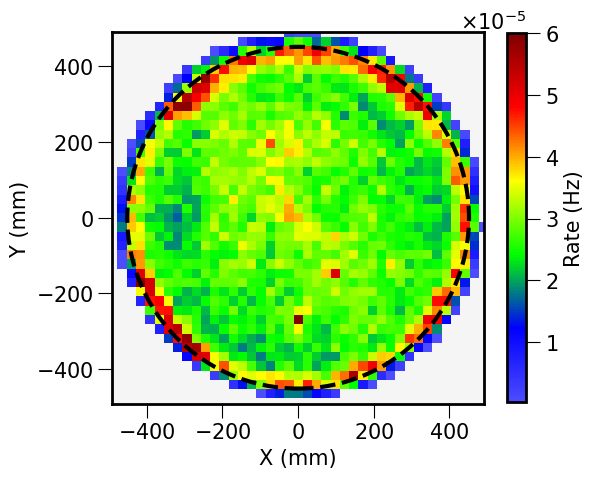

In [72]:
# Global
n_bins = 50

# Dataframe
data = ELEC_INCL_RAS_ON_DF

# Variables
X = data['X_bary'].unique()
Y = data['Y_bary'].unique()

# 2D histogram: normalized by corrected DAQ data taking time
XY_hit_map, ex, ey = pt.mapping(X, Y, xy_bins=n_bins, pos=True)
XY_rate            = XY_hit_map / RAS_ON_CORRECTED_TIME             # Normalized to rate      
XY_rate            = np.ma.masked_where(XY_rate == 0, XY_rate)      # Zero values masked
XY_rate            = np.clip(XY_rate, 0, 6e-5)

# ----- Plotting ----- #
plt.figure(figsize=(6, 6))
im = plt.pcolormesh(ex, ey, XY_rate.T, cmap=pt.custom_hsv, shading='auto')
cbar = plt.colorbar(im, label='Rate (Hz)', shrink=0.80)
cbar.formatter.set_powerlimits((-3, 3))

plt.xlabel('X (mm)')
plt.xlim(-pt.N100_rad, pt.N100_rad)
plt.ylabel('Y (mm)')
plt.ylim(-pt.N100_rad, pt.N100_rad)

# R-lim
plt.gca().add_patch(pt.plot_circle(R_UP, LINESTYLE='--'))
plt.gca().set_aspect('equal', adjustable='box')
plt.gca().set_facecolor("whitesmoke")
# plt.tight_layout()
plt.show()

## Inclusive/Fiducial

### Z Distribution

In [73]:
print(ELEC_INCL_RAS_ON_DF['global_event'].nunique())
ELEC_INCL_RAS_ON_DF

120713


,event,npeak,E_peak_pe,n_hits_peak,X_bary,Y_bary,Z_bary,Z_min,Z_max,R_max,...,nS1,nS2,S1e_max,S1e_corr_max,n_hits_original,run_number,global_event,particle,region,E_evt_mev
2,3102,28,105878.602295,293,-383.024576,249.118346,136.800675,136.444451,145.976535,572.328604,...,0,1,NaN,NaN,869,15625,2,electron,anode,0.517617
21,16416,39,507654.634918,2610,153.242465,-59.128367,814.948924,789.301255,847.492616,498.469725,...,1,1,578.695923,687.353834,3510,15625,21,electron,tube,2.446142
28,24179,38,147404.216751,417,-251.670536,365.606790,321.436811,304.616346,338.565109,498.467844,...,1,1,129.498611,202.565292,758,15625,28,electron,tube,0.716940
32,26181,30,130226.652027,410,38.554585,247.627791,318.886611,261.444088,381.408775,339.263506,...,1,1,90.630959,146.678337,750,15625,32,electron,fiducial,0.634488
40,30920,28,312293.863779,1099,108.943233,-121.984925,305.257621,280.342607,337.997561,294.945709,...,1,1,237.644119,376.526013,1612,15625,40,electron,fiducial,1.508411
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1005311,1747949,31,110227.156756,298,314.892995,-246.857926,22.116870,4.768529,38.186723,478.361695,...,0,1,NaN,NaN,500,15737,939899,electron,anode,0.538490
1005321,1757637,25,97136.544046,260,102.497306,159.552241,67.881718,18.287398,261.671799,487.977096,...,0,2,NaN,NaN,663,15737,939907,electron,anode,0.581885
1005322,1757637,26,22131.080577,81,102.497306,159.552241,67.881718,18.287398,261.671799,487.977096,...,0,2,NaN,NaN,663,15737,939907,electron,anode,0.581885
1005340,1774157,23,635195.231866,3088,129.104012,-7.037664,1186.062069,1168.705176,1206.102262,489.914917,...,1,1,884.176819,884.557759,4126,15737,939922,electron,cathode,3.058337


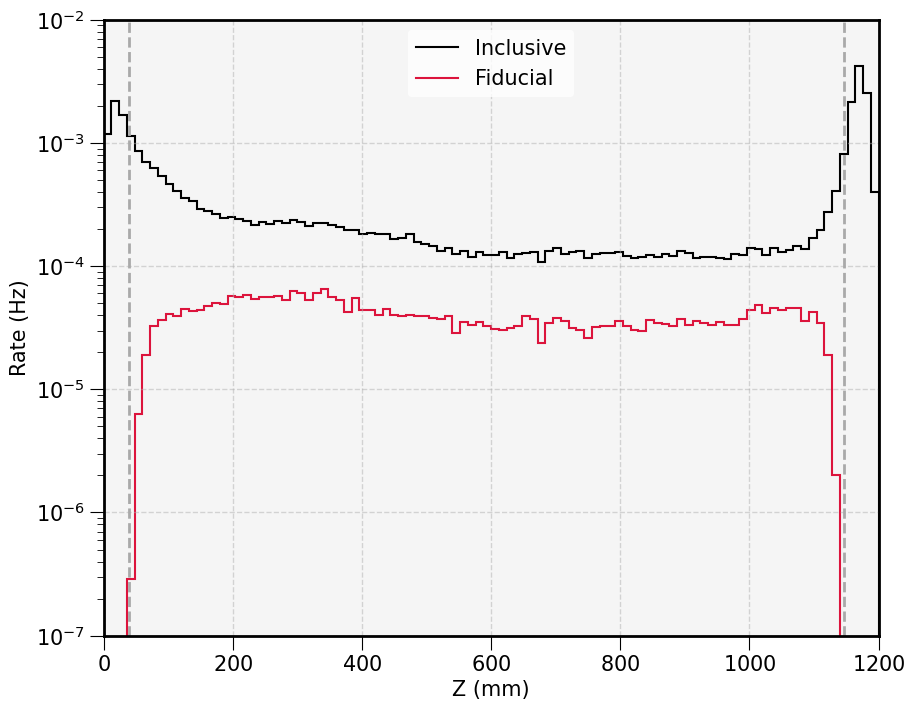

In [74]:
# Global
n_bins = 100

# ----- Define the Binning ----- #
# Use the "Inclusive" region to define the binning
_, plot_edges = np.histogram(ELEC_INCL_RAS_ON_DF['Z_bary'].unique(), bins=n_bins, range=(0, 1200))


for i, dataframe in enumerate([ELEC_INCL_RAS_ON_DF, ELEC_FIDU_RAS_ON_DF]):

    # Variable
    Z_evt = dataframe['Z_bary'].unique()

    # Histogram
    counts, bin_edges = np.histogram(Z_evt, bins=plot_edges)
    rate = counts / (RAS_ON_CORRECTED_TIME)  # in [Hz]

    # Labels
    if i == 0:
        label = 'Inclusive'
    else:
        label = 'Fiducial'

    # ----- Plotting ----- #
    plt.stairs(rate, bin_edges, label=f'{label}', 
               fill=False, lw=1.5, ec=pt.hist_colors[i % len(pt.hist_colors)])

# Lines
plt.axvline(x=Z_LOW, c='darkgray', ls='--')
plt.axvline(x=Z_UP, c='darkgray', ls='--')

# ----- Styling ----- #
plt.xlabel('Z (mm)')
plt.xlim(0, 1200)
plt.ylabel('Rate (Hz)')
plt.ylim(1e-7, 1e-2)
plt.yscale('log')
plt.legend(loc='upper center')

plt.grid(True)
plt.gca().set_facecolor("whitesmoke")
# plt.savefig('/lhome/ific/c/ccortesp/Analysis/NEXT-100/Backgrounds/images/Z_Bckg_Inclusive_Fiducial.pdf')
plt.show()

### $R^{2}$ Distribution

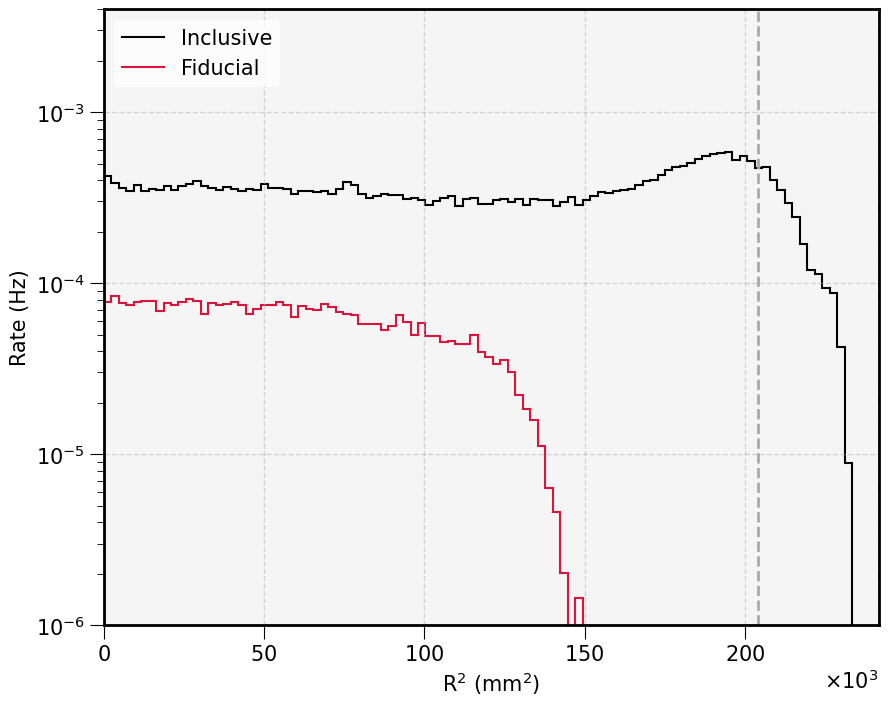

In [75]:
# Global
n_bins = 100

# ----- Define the Binning ----- #
# Use the "Inclusive" region to define the binning
# Dataframe
data = ELEC_INCL_RAS_ON_DF.copy()

# Variables
X_evt = data['X_bary'].unique()
Y_evt = data['Y_bary'].unique()
R2_evt = X_evt**2 + Y_evt**2
_, plot_edges = np.histogram(R2_evt, bins=n_bins)

for i, dataframe in enumerate([ELEC_INCL_RAS_ON_DF, ELEC_FIDU_RAS_ON_DF]):

    # Variable
    X = dataframe['X_bary'].unique()
    Y = dataframe['Y_bary'].unique()
    R2 = X**2 + Y**2

    # Histogram
    counts, bin_edges = np.histogram(R2, bins=plot_edges)
    rate = counts / (RAS_ON_CORRECTED_TIME)  # in [Hz]

    # Labels
    if i == 0:
        label = 'Inclusive'
    else:
        label = 'Fiducial'

    # ----- Plotting ----- #
    plt.stairs(rate, bin_edges, label=f'{label}', 
               fill=False, lw=1.5, ec=pt.hist_colors[i % len(pt.hist_colors)])

# Lines
plt.axvline(x=R_UP**2, c='darkgray', ls='--')
plt.axvline(x=pt.N100_rad**2, c='darkgray', ls='--')

# ----- Styling ----- #
plt.xlabel(r'R$^{2}$ (mm$^{2}$)')
plt.xlim(0, pt.N100_rad**2)
plt.ylabel('Rate (Hz)')
plt.ylim(1e-6, 4e-3)
plt.ticklabel_format(axis='x', style='sci', scilimits=(3, 3))
plt.yscale('log')
plt.legend(loc='upper left')

plt.grid(True)
plt.gca().set_facecolor("whitesmoke")
plt.savefig('/lhome/ific/c/ccortesp/Analysis/NEXT-100/Backgrounds/images/R2_Bckg_Inclusive_Fiducial.pdf')
plt.show()

### E Distribution

Center of the DEP bin: 1.6625 MeV
Shift value: 0.0695 MeV
Inclusive in range: counts = 90571, corr. time = 3485614.53 s | Rate = 0.0260 Hz
Fiducial in range: counts = 9915, corr. time = 3485614.53 s | Rate = 0.0028 Hz


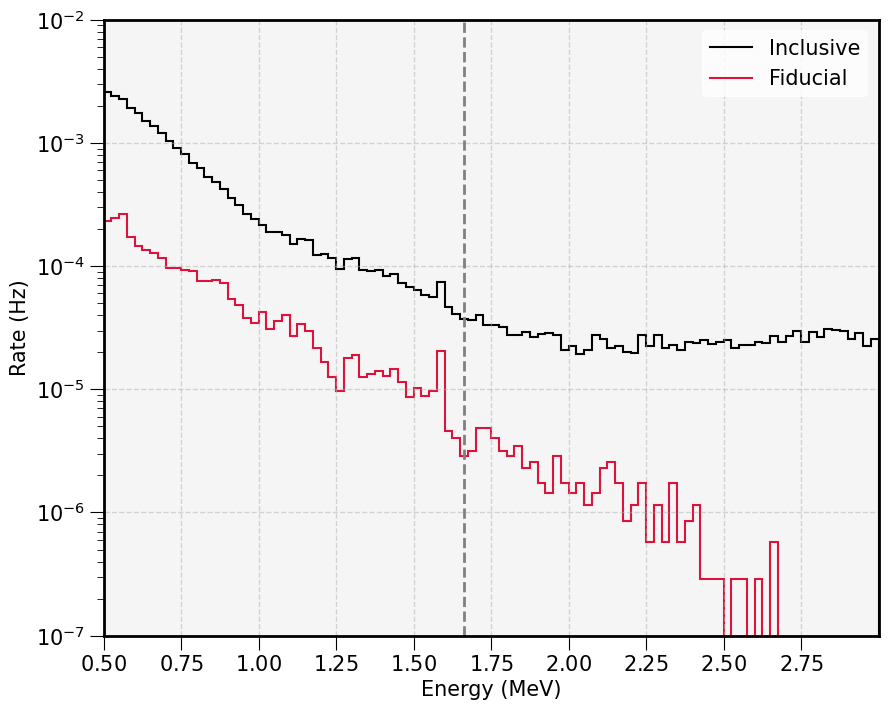

In [ ]:
# Global
n_bins = 100
DEP_VALUE = 1.593       # MeV

# ----- Define the Binning ----- #
# Use the "Inclusive" region to define the binning
_, plot_edges = np.histogram(ELEC_INCL_RAS_ON_DF['E_evt_mev'].unique(), bins=n_bins, range=(0.5, 3))

# ----- Shifting the Histogram ----- #
# Use the "Fiducial" data that includes DEP peak 
E_counts_fid, _ = np.histogram(ELEC_FIDU_RAS_ON_DF['E_evt_mev'].unique(), bins=plot_edges)
# Mask around DEP peak
mask = (plot_edges[:-1] >= 1.55) & (plot_edges[:-1] <= 1.75)  
bin_centers = (plot_edges[:-1] + plot_edges[1:]) / 2
# Find the bin with the highest count in the specified range
peak_bin_index  = np.argmax(E_counts_fid[mask])
peak_bin_center = bin_centers[mask][peak_bin_index]
print(f"Center of the DEP bin: {peak_bin_center:.4f} MeV")
shift_value = peak_bin_center - DEP_VALUE
print(f"Shift value: {shift_value:.4f} MeV")

for i, dataframe in enumerate([ELEC_INCL_RAS_ON_DF, ELEC_FIDU_RAS_ON_DF]):

    # Variable
    E_evt = dataframe['E_evt_mev'].unique() - shift_value

    # Histogram
    counts, bin_edges = np.histogram(E_evt, bins=plot_edges)
    rate = counts / (RAS_ON_CORRECTED_TIME)  # in [Hz]

    # Labels
    if i == 0:
        label = 'Inclusive'
    else:
        label = 'Fiducial'

    print(f"{label} in range: counts = {counts.sum()}, corr. time = {RAS_ON_CORRECTED_TIME:.2f} s | Rate = {rate.sum():.4f} Hz")

    # ----- Plotting ----- #
    plt.stairs(rate, bin_edges, label=f'{label}', 
               fill=False, lw=1.5, ec=pt.hist_colors[i % len(pt.hist_colors)])

# Lines
plt.axvline(peak_bin_center, c='gray', ls='--')
plt.axvline(x=DEP_VALUE, c='gray', ls='--')

# ----- Styling ----- #
plt.xlabel('Energy (MeV)')
plt.xlim(0.5, 3)
plt.xticks(np.arange(0.5, 3.0, 0.25))
plt.ylabel('Rate (Hz)')
plt.ylim(1e-7, 1e-2)
plt.yscale('log')
plt.legend(loc='upper right')

plt.grid(True)
plt.gca().set_facecolor("whitesmoke")
# plt.savefig('/lhome/ific/c/ccortesp/Analysis/NEXT-100/Backgrounds/images/Energy_Bckg_Inclusive_Fiducial.pdf')
plt.show()

What are those _high energy_ events?! Yep those above $2.6$ MeV...

In [65]:
over_2_6_MeV_ids = ELEC_INCL_RAS_ON_DF.loc[ELEC_INCL_RAS_ON_DF['E_evt_mev'] >= 2.6, 'global_event'].unique()
over_2_6_MeV_df = ELEC_INCL_RAS_ON_DF.loc[ELEC_INCL_RAS_ON_DF['global_event'].isin(over_2_6_MeV_ids)].copy()

In [38]:
over_2_6_MeV_df

,event,npeak,E_peak_pe,n_hits_peak,X_bary,Y_bary,Z_bary,Z_min,Z_max,R_max,...,nS1,nS2,S1e_max,S1e_corr_max,n_hits_original,run_number,global_event,particle,region,E_evt_mev
2783,19224,26,5.455293e+05,2430,-19.738224,41.712058,641.697165,566.536940,742.304832,488.068255,...,1,1,558.804504,710.183553,3184,15625,2668,electron,tube,2.627941
2945,128977,36,1.017441e+06,7033,-93.362034,-0.138485,1182.809113,1164.532524,1201.831973,492.737969,...,1,1,253.671021,254.136011,7673,15625,2823,electron,cathode,4.893115
4497,1280169,25,5.849150e+05,1927,186.288550,-127.963307,278.428532,232.600987,325.284007,494.520987,...,1,1,484.453552,771.969892,2680,15625,4309,electron,tube,2.816992
4929,1605515,29,6.299369e+05,2371,345.482975,-73.429395,419.626082,374.786659,470.815608,495.788152,...,1,1,538.642456,794.186040,3236,15625,4729,electron,tube,3.033097
7226,1205928,26,5.566696e+05,1837,228.166937,-156.800447,200.617417,117.246317,289.042886,494.520987,...,1,1,431.895905,754.976870,2618,15625,6948,electron,tube,2.681414
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1000364,317175,25,5.927513e+05,2978,258.307199,-106.568080,947.326926,348.211643,1094.843583,498.571751,...,1,3,50.581512,75.083257,4820,15737,935341,electron,tube,3.536289
1000516,474465,25,5.743555e+05,2321,-211.806788,-256.676756,1185.960714,1168.719449,1202.574468,489.914917,...,1,1,737.726318,738.024051,3476,15737,935482,electron,cathode,2.766306
1001258,1235680,32,5.571820e+05,2184,13.784194,-38.340655,1186.023188,1168.042694,1205.437617,490.317200,...,1,1,746.278870,746.533412,3372,15737,936167,electron,cathode,2.683874
1002634,864191,26,6.399096e+05,2250,-6.411376,-24.019190,384.850940,323.278504,453.965083,498.469725,...,1,1,512.540344,796.178204,2980,15737,937423,electron,tube,3.080966


## RAS ON/OFF

### Z Distribution

RAS: off in range: counts = 3366, corr. time = 697798.63 s | Rate = 0.0048 Hz
RAS: on in range: counts = 12570, corr. time = 3485614.53 s | Rate = 0.0036 Hz


/tmp/ccortesp/ipykernel_266988/2815506879.py:38: RuntimeWarning: divide by zero encountered in divide
  Z_ras_on_off_hist['counts'] = rate_ras_on / rate_ras_off
/tmp/ccortesp/ipykernel_266988/2815506879.py:38: RuntimeWarning: invalid value encountered in divide
  Z_ras_on_off_hist['counts'] = rate_ras_on / rate_ras_off


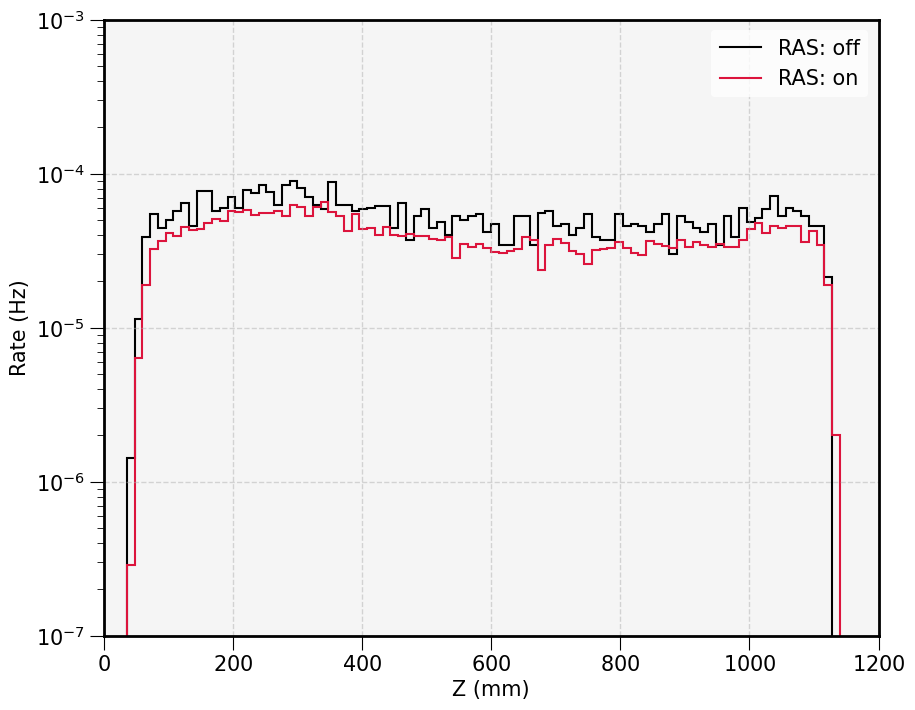

In [76]:
# Global
n_bins = 100

# Storage
Z_ras_on_off_hist = {}
rate_ras_on  = []
rate_ras_off = []

# ----- Define the Binning ----- #
# Use the "Inclusive" region to define the binning
_, plot_edges = np.histogram(ELEC_FIDU_RAS_ON_DF['Z_bary'].unique(), bins=n_bins, range=(0, 1200))

for i, dataframe in enumerate([ELEC_FIDU_RAS_OFF_DF, ELEC_FIDU_RAS_ON_DF]):

    # Variable
    Z_evt = dataframe['Z_bary'].unique()

    # Histogram
    counts, bin_edges = np.histogram(Z_evt, bins=plot_edges)
    corr_time = RAS_OFF_CORRECTED_TIME if i == 0 else RAS_ON_CORRECTED_TIME
    rate = counts / (corr_time)  # in [Hz]

    # Labels
    if i == 0:
        label = 'RAS: off'
        rate_ras_off = rate
    else:
        label = 'RAS: on'
        rate_ras_on = rate

    print(f"{label} in range: counts = {counts.sum()}, corr. time = {corr_time:.2f} s | Rate = {rate.sum():.4f} Hz")

    # ----- Plotting ----- #
    plt.stairs(rate, bin_edges, label=f'{label}', 
               fill=False, lw=1.5, ec=pt.hist_colors[i % len(pt.hist_colors)])

Z_ras_on_off_hist['bin_edges'] = bin_edges
Z_ras_on_off_hist['counts'] = rate_ras_on / rate_ras_off

# ----- Styling ----- #
plt.xlabel('Z (mm)')
plt.xlim(0, 1200)
plt.ylabel('Rate (Hz)')
plt.ylim(1e-7, 1e-3)
plt.yscale('log')
plt.legend(loc='upper right')

plt.grid(True)
plt.gca().set_facecolor("whitesmoke")
plt.savefig('/lhome/ific/c/ccortesp/Analysis/NEXT-100/Backgrounds/images/Z_Bckg_RAS_On_Off_Comparison.pdf')
plt.show()

Let's see the rate of both dataframes!

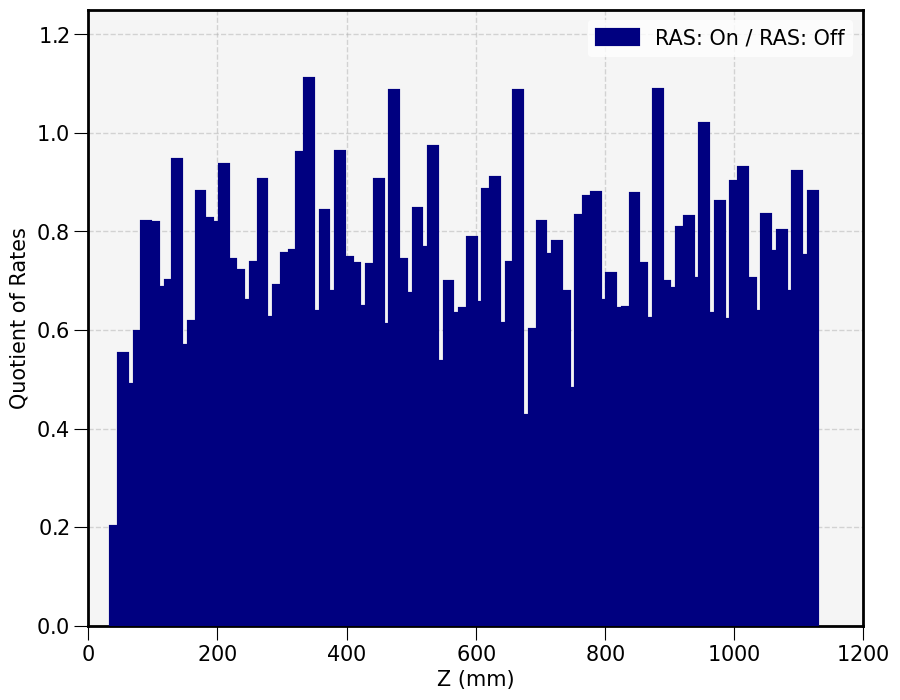

In [95]:
# Filter out NaN/Inf values
valid_counts = np.isfinite(Z_ras_on_off_hist['counts'])
filtered_counts = Z_ras_on_off_hist['counts'][valid_counts]
filtered_bin_edges = Z_ras_on_off_hist['bin_edges'][:-1][valid_counts]
bin_width = Z_ras_on_off_hist['bin_edges'][1] - Z_ras_on_off_hist['bin_edges'][0]

# ----- Plotting ----- #
plt.bar(filtered_bin_edges, filtered_counts, width=bin_width, 
       align='edge', label='RAS: On / RAS: Off', color='navy', edgecolor='navy', zorder=3)

# Styling
plt.xlabel('Z (mm)')
plt.xlim(0, 1200)
plt.ylabel('Quotient of Rates')
plt.ylim(0, 1.25)
# plt.yscale('log')
plt.legend(loc='upper right')

plt.grid(True)
plt.gca().set_facecolor("whitesmoke")
# plt.savefig('/lhome/ific/c/ccortesp/Analysis/NEXT-100/Backgrounds/images/Z_Bckg_RAS_On_Off_Quotient.pdf')
plt.show()

### E Distribution

Center of the DEP bin: 1.68
Shift value: 0.08 MeV
RAS: off in range: counts = 2621, corr. time = 697798.63 s | Rate = 0.0038 Hz
RAS: on in range: counts = 9731, corr. time = 3485614.53 s | Rate = 0.0028 Hz


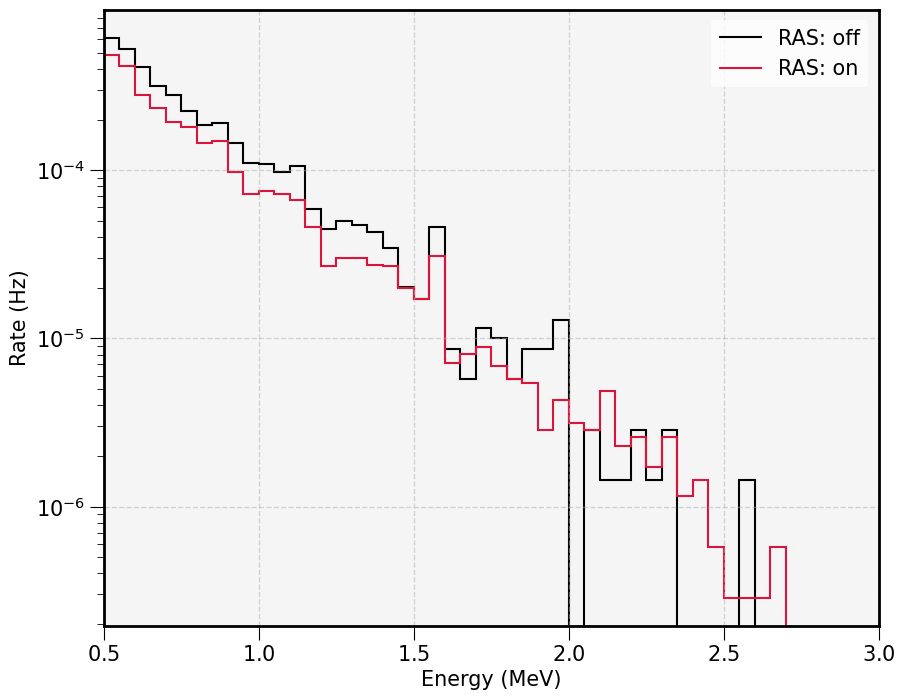

In [59]:
# Global
n_bins = 50
DEP_VALUE = 1.6       # MeV

# Storage
E_ras_on_off_hist = {}
rate_ras_on  = []
rate_ras_off = []

# ----- Define the Binning ----- #
# Use the "Inclusive" region to define the binning
_, plot_edges = np.histogram(ELEC_FIDU_RAS_ON_DF['E_evt_mev'].unique(), bins=n_bins, range=(0.5, 3))

# ----- Shifting the Histogram ----- #
# Use the "Fiducial" data that includes DEP peak 
E_counts_fid, _ = np.histogram(ELEC_FIDU_RAS_ON_DF['E_evt_mev'].unique(), bins=plot_edges)
# Mask around DEP peak
mask = (plot_edges[:-1] >= 1.55) & (plot_edges[:-1] <= 1.75)  
bin_centers = (plot_edges[:-1] + plot_edges[1:]) / 2
# Find the bin with the highest count in the specified range
peak_bin_index  = np.argmax(E_counts_fid[mask])
peak_bin_center = bin_centers[mask][peak_bin_index]
print(f"Center of the DEP bin: {peak_bin_center:.2f}")
shift_value = peak_bin_center - DEP_VALUE
print(f"Shift value: {shift_value:.2f} MeV")

for i, dataframe in enumerate([ELEC_FIDU_RAS_OFF_DF, ELEC_FIDU_RAS_ON_DF]):

    # Variable
    E_evt = dataframe['E_evt_mev'].unique() - shift_value

    # Histogram
    counts, bin_edges = np.histogram(E_evt, bins=plot_edges)
    corr_time = RAS_OFF_CORRECTED_TIME if i == 0 else RAS_ON_CORRECTED_TIME
    rate = counts / (corr_time)  # in [Hz]

    # Labels
    if i == 0:
        label = 'RAS: off'
        rate_ras_off = rate
    else:
        label = 'RAS: on'
        rate_ras_on = rate

    print(f"{label} in range: counts = {counts.sum()}, corr. time = {corr_time:.2f} s | Rate = {rate.sum():.4f} Hz")

    # ----- Plotting ----- #
    plt.stairs(rate, bin_edges, label=f'{label}', 
               fill=False, lw=1.5, ec=pt.hist_colors[i % len(pt.hist_colors)])

E_ras_on_off_hist['bin_edges'] = bin_edges
E_ras_on_off_hist['counts'] = rate_ras_off - rate_ras_on

# ----- Styling ----- #
plt.xlabel('Energy (MeV)')
plt.xlim(0.5, 3)
plt.ylabel('Rate (Hz)')
# plt.ylim(1e-7, 1e-3)
plt.yscale('log')
plt.legend(loc='upper right')

plt.grid(True)
plt.gca().set_facecolor("whitesmoke")
# plt.savefig('/lhome/ific/c/ccortesp/Analysis/NEXT-100/Backgrounds/images/Energy_Bckg_RAS_On_Off_Comparison.pdf')
plt.show()

And the quotient...

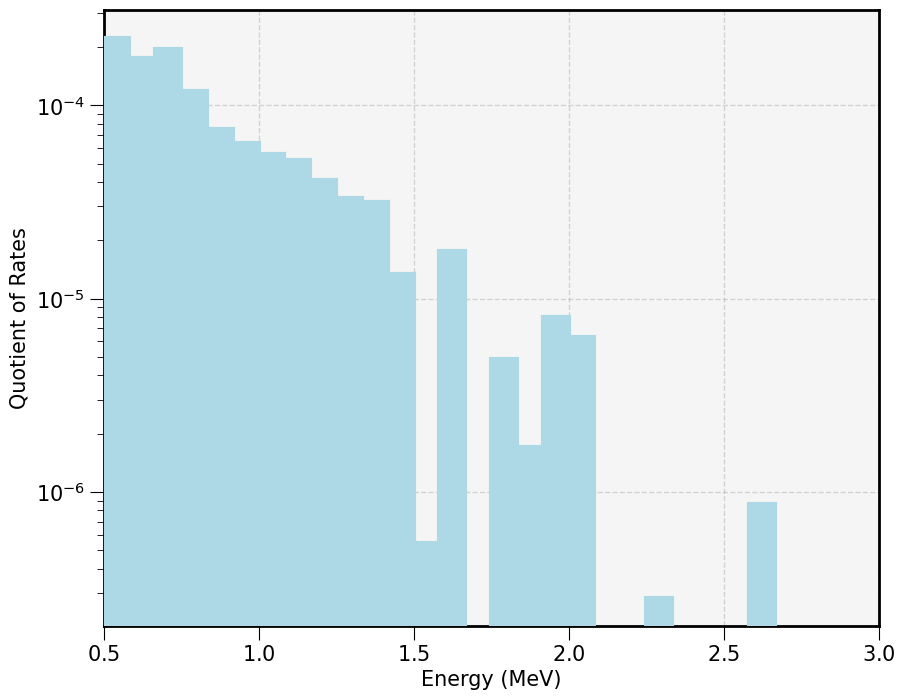

In [58]:
# Filter out NaN/Inf values
valid_counts = (E_ras_on_off_hist['counts'] >= 0) 
filtered_counts = E_ras_on_off_hist['counts'][valid_counts]
filtered_bin_edges = E_ras_on_off_hist['bin_edges'][:-1][valid_counts]
bin_width = E_ras_on_off_hist['bin_edges'][1] - E_ras_on_off_hist['bin_edges'][0]

# ----- Plotting ----- #
plt.bar(filtered_bin_edges, filtered_counts, width=bin_width, 
       align='edge', label='RAS: On / RAS: Off', color='lightblue', edgecolor='lightblue', zorder=3)

# Styling
plt.xlabel('Energy (MeV)')
plt.xlim(0.5, 3)
plt.ylabel('Quotient of Rates')
# plt.ylim(0, 2)
plt.yscale('log')
# plt.legend(loc='upper right')

plt.grid(True)
plt.gca().set_facecolor("whitesmoke")
# plt.savefig('/lhome/ific/c/ccortesp/Analysis/NEXT-100/Backgrounds/images/Energy_Bckg_RAS_On_Off_Quotient.pdf')
plt.show()